# VMT Reduction Likelihood Analysis

The purpose of this script is to define a set of rules that classify which trips in the TBI are the most likely switch to another mode. These trips will be a subset of the feasible trips and will satisfy more stringent conditions than the feasibility analysis, as even if a switch is feasible, that does not mean a person is likely to do it. The result of this analysis will be a set of binary flags attached to each TBI record where the mode is car:

    likely_walk_shift    - this trip is a trip that is most likely to switch to walk
    likely_bike_shift    - this trip is a trip that is most likely to switch to bike
    likely_transit_shift - this trip is a trip that is most likely to switch to transit
    likely_shift         - this trip is a trip that is most likely to switch to any non-car mode

In all cases, the flag starts as 1 (feasible) and we set it to infeasible if it violates one or more of our rules.  Even though our interst is in understanding which car trips could switch to another mode, we code this flag for all modes.  This way, we can see how existing trips on that mode violate the feasibility rules.  In general, we aim to follow the "95% rule" such that 95% of trips that currently use that mode meet the feasibility condition.  Therefore, about 5% of trips will violate our own rules.  This is ok, because these trips are the most dedicated users of that mode, and new users will likely be less dedicated.  

The list below shows several of the factors we wish to test.  

### Definition of what makes a trip be more likely to engage in a mode shift

- duration differences (15 minute threshold to start with w.r.t to the car trip)
- disability -- only transit is likely
- timing without any overlaps in trips
- weather for walking (no walking when there is rain)
- weather for biking (no biking when there is rain)
- number of transfers (0 is likely)
- temperature > 12 degrees (walking and biking)
- light outside (walking and biking)
- shopping purpose/escort purpose should only be car

- any lts 3 or 4 distance -- biking unlikely

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
import math
import keyring
import itertools
from ast import literal_eval

In [3]:
from suncalc import get_position, get_times
from datetime import datetime as dt
import pytz

In [4]:
# This is used to avoid hard-coding directories. 
# To set the directory, use the command prompt or a notebook you don't check in.  run:
# import keyring
# keyring.set_password("msp", "vmt_reduction_dir", <directory>)

# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [5]:
raw = pd.read_csv(data_dir + "/Data_Processed/feasible_shifts.csv")

C:\Users\fishl\AppData\Local\Temp\ipykernel_21240\866335667.py:1: DtypeWarning: Columns (34,35,36,53,65,66,67,68,69,70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(data_dir + "/Data_Processed/feasible_shifts.csv")


In [6]:
# only consider trips that are a feasible shift; feasibility is a necessity for a trip being likely
df = raw.loc[raw["feasible_shift"], :].copy()

In [7]:
# reading in weather data
# https://www.ncei.noaa.gov/pub/data/ghcn/daily/
weather = pd.read_csv("extra_data/USW00014922.csv")
weather = weather[["Date", "Measurement", "Value"]]
weather = weather.pivot(index="Date", columns="Measurement", values="Value")
weather

C:\Users\fishl\AppData\Local\Temp\ipykernel_21240\2067923688.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv("extra_data/USW00014922.csv")


Measurement,ACMH,ACSH,ADPT,ASLP,ASTP,AWBT,AWND,FMTM,FRGT,PGTM,...,WT16,WT17,WT18,WT19,WT21,WT22,WV01,WV03,WV07,WV20
Date,,,,,,,,,,,,,,,,,,,,,
19380409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20230311,NaN,NaN,NaN,NaN,NaN,NaN,57.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20230312,NaN,NaN,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20230313,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
weather["year"] = weather.index.astype(str).str[0:4]
weather["month"] = weather.index.astype(str).str[4:6]
weather["day"] = weather.index.astype(str).str[6:8]
weather["date"] = weather["year"] + "-" + weather["month"] + "-" + weather["day"]
weather = weather.set_index("date")
weather

Measurement,ACMH,ACSH,ADPT,ASLP,ASTP,AWBT,AWND,FMTM,FRGT,PGTM,...,WT19,WT21,WT22,WV01,WV03,WV07,WV20,year,month,day
date,,,,,,,,,,,,,,,,,,,,,
1938-04-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,09
1938-04-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,10
1938-04-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,11
1938-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,12
1938-04-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-11,NaN,NaN,NaN,NaN,NaN,NaN,57.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,03,11
2023-03-12,NaN,NaN,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,03,12
2023-03-13,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,03,13


As before, there are also configurable thresholds to tweak the likelihood analysis thresholds and figures shown in this notebook.

In [9]:
#| echo: true
MAX_PROBABLE_DIST = 15
MAX_PROBABLE_DIST_PCT = 0.5
MAX_PROBABLE_RAIN = 0
MIN_PROBABLE_TEMPERATURE = 12
MIN_PROBABLE_TEMPERATURE_PCT = 0.5
MAX_PROBABLE_TRANFERS = 0
MAX_HIGH_LTS_DIST_BIKE = 0
MAX_HIGH_LTS_DIST_BIKE_PCT = 0.5

unlikely_purposes = ["Escort", "Shop"]

As before, all feasible trips are the most likely to switch to switch to an alternative mode initially.

In [10]:
#| echo: true
# everything is feasible initially
df['likely_walk_shift'] = True
df['likely_bike_shift'] = True
df['likely_transit_shift'] = True
df['likely_shift'] = True

In [11]:
#| echo: true
# omit schools bus and taxi/ridehail/carshare -- very different from other modes
valid_modes = [("Car","distance"), 
               ("Bike/Scooter","distance"), 
               ("Walk","distance"), 
               ("Transit","distance")]

In [12]:
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

In [13]:
def plot_mode_density(df: pd.DataFrame, modes=valid_modes, percentile=0.95, size=(12, 6), bins=300, function=lambda x: x):
    palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
    fig, ax = plt.subplots(figsize=size)
    for m in modes: # cycle through all modes
        mode = m[0]
        column = m[1]
        label = mode + ' ' + column
        
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(function(group[column]), ax=ax, stat="density", kde=True, label=label, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = function(group[column]).quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        plt.axvline(x=val, color=c) # plot line representing that value on the plot        
        plt.legend()
    return fig, ax

In [14]:
def show_summaries(df: pd.DataFrame, modes=valid_modes, percentile=[0.95]): # show normal summaries for each mode side by side
    res = []
    labels = []
    if type(percentile) != type([]):
        percentile = [percentile]
    p = [0.25, 0.5, 0.75]
    p += percentile
    p = list(set(p))
    for m in modes:        
        mode = m[0]
        column = m[1]
        labels.append(mode + ' ' + column)
        
        group = df[df["mode"] == mode]
        res.append(group[column].describe(percentiles=p))
    x = pd.concat(res, axis=1)
    x.columns = labels
    return x

In [15]:
def plot_multi_barplot(df: pd.DataFrame, x: str, y: str, figsize=(7, 5), order=None):
    # plot normalized bar plot of the values in each mode side by side
    fig, ax = plt.subplots(figsize=figsize)
    if y == "mode": 
        df = df[df["mode"].isin([x[0] for x in valid_modes])]
    (df
     .groupby(y)[x]
     .value_counts(normalize=True)
     .mul(100)
     .rename("percent")
     .reset_index()
     .pipe((sns.barplot, "data"), x=x, y="percent", hue=y, ax=ax, order=order)
    )
    
    return fig, ax

## 1. Difference between durations of alternative mode and car mode > X minutes

Even if switching from a car mode to a non-car mode is considered feasible in terms of the factors discussed previously, a person may not be likely to choose to do so if the time difference is too great. Here we consider a 15 minute maximum between a non-car mode and car mode as a trip that is more likely to switch.

### 1a. Bike duration difference (later, convert this cutoff to one based on the data)

Below, a distribution of the difference between rerouted car trip and bike trip durations are shown for both observed car and bike trips.

The specified percentile is also shown with vertical lines. The percentiles are flipped here as the left represents more un-ideal conditions, which makes the consideration of these flipped percentiles more meaningful in gauging trip shift likelihood. 

If the specified percentile is used as a criteria, then any of the orange trips to the left of the blue line could more likely shift to biking.

In [16]:
df["car_minus_bike"] = df["car_duration_seconds"] / 60 - df["bike_weight"] / 60

Text(0.5, 1.0, 'Comparison of distribution of car minus bike durations for observed bike/car trips')

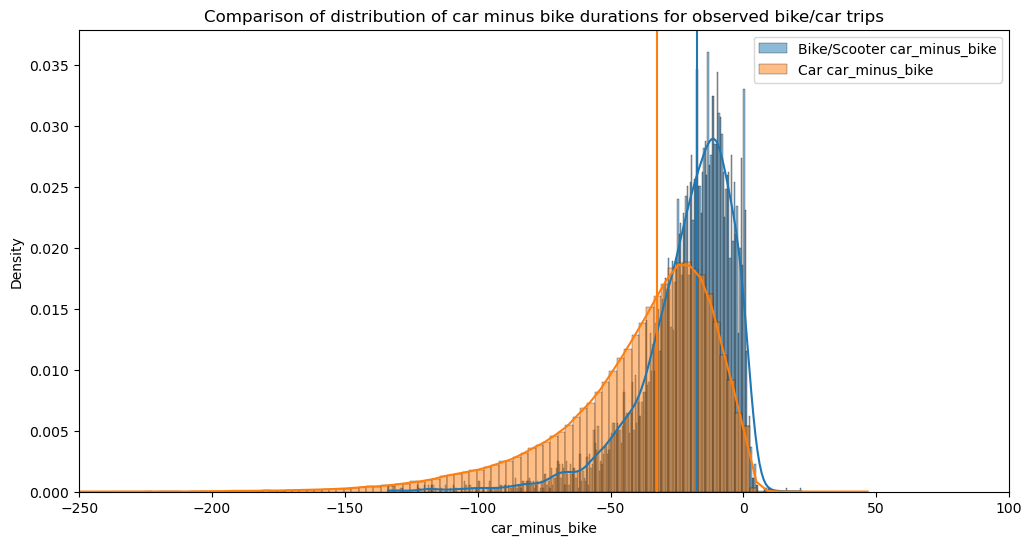

In [17]:
#| output: true

fig, ax = plot_mode_density(df, [('Bike/Scooter','car_minus_bike'), ('Car','car_minus_bike')], percentile= 1 - MAX_PROBABLE_DIST_PCT) 
ax.set_xlim(-250, 100)
plt.title("Comparison of distribution of car minus bike durations for observed bike/car trips")

Below we can see the summary statistics for the above distribution. Nothing is too shocking, with the statistics reflecting what was seen with the graph.

In [18]:
#| output: true

show_summaries(df, modes= [('Bike/Scooter','car_minus_bike'), ('Car','car_minus_bike')], percentile= 1 - MAX_PROBABLE_DIST_PCT)

,Bike/Scooter car_minus_bike,Car car_minus_bike
count,6846.000000,204305.000000
mean,-21.241914,-39.538770
std,18.244027,29.683912
min,-133.728333,-786.380000
25%,-29.173750,-52.898333
50%,-17.390833,-32.406667
75%,-8.704167,-18.590000
max,21.691667,46.761667


In [19]:
df["duration_minus_bike"] = df["duration"] - df["bike_weight"] / 60
df[df["mode"] == "Car"]["duration_minus_bike"].describe(percentiles=[0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95])

count    204306.000000
mean        -33.285291
std          34.460253
min        -786.408333
25%         -48.505000
50%         -27.975000
75%         -13.656667
80%         -10.566667
85%          -7.231667
90%          -2.998333
95%           3.421250
max         851.015000
Name: duration_minus_bike, dtype: float64

By adding a condition for the maximum duration difference between biking and car duration to account for the increases in duration when shifting to biking and the corresponding loss of utility, we reduce the percentage of car trips that are most likely to switch to an alternative mode.

In [20]:
#| output: true

# require all bike trips to occur via 250 meters or less on lts 3/4 roads
df["likely_biking_car_duration_diff"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum()

df.loc[df["duration_minus_bike"] < -1 * MAX_PROBABLE_DIST, 'likely_bike_shift'] = False
df.loc[df["duration_minus_bike"] < -1 * MAX_PROBABLE_DIST, 'likely_biking_car_duration_diff'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")


Before constraint  100.0  percent of car trips could shift to biking.
After constraint  27.407907746223803  percent of car trips could shift to biking.


In [21]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_bike_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to biking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to biking.".format(df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 100.0% of VMT could be mitigated by switches to biking.
After this constraint, 13.005465936681611% of VMT could be mitigated by switches to biking.


### 1b. Walk duration difference (later, convert this cutoff to one based on the data)

Below, a distribution of the difference between observed car trips durations on a car mode versus a walking alternative. This distribution is overlayed on the inverse--the difference between car durations for observed walking trips and their corresponding observed biking durations. 

The specified percentile is also shown with vertical lines. The percentiles are flipped here as the left represents more un-ideal conditions, which makes the consideration of these flipped percentiles more meaningful in gauging trip shift likelihood. 

If the specified percentile is used as a criteria, then any of the orange trips to the left of the blue line could more likely shift to walking. This logic is essentially the same that was explained in the biking duration difference section.

In [22]:
df["car_minus_walk"] = df["car_duration_seconds"] / 60 - df["walk_duration_seconds"] / 60

Text(0.5, 1.0, 'Comparison of distribution of car minus bike durations for observed walk/car trips')

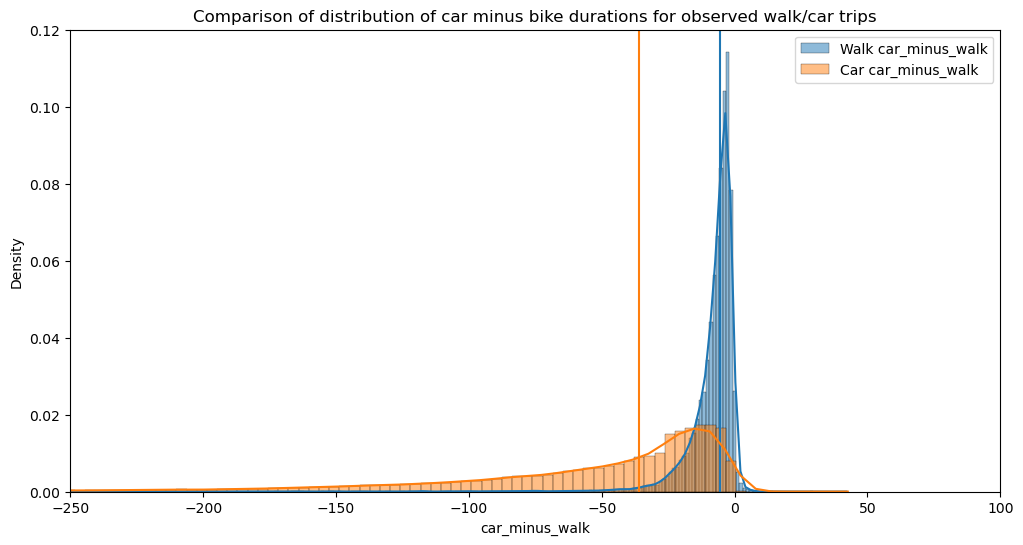

In [23]:
#| output: true

fig, ax = plot_mode_density(df, [('Walk','car_minus_walk'), ('Car','car_minus_walk')], percentile= 1 - MAX_PROBABLE_DIST_PCT) 
ax.set_xlim(-250, 100)
plt.title("Comparison of distribution of car minus bike durations for observed walk/car trips")

The corresponding summary statistics for the above graph are shown below.

In [24]:
#| output: true

show_summaries(df, modes=[('Walk','car_minus_walk'), ('Car','car_minus_walk')], percentile= 1 - MAX_PROBABLE_DIST_PCT)

,Walk car_minus_walk,Car car_minus_walk
count,46658.000000,204305.000000
mean,-8.320396,-57.945713
std,11.737361,61.740432
min,-335.740000,-1105.853333
25%,-9.956667,-78.806667
50%,-5.466667,-36.000000
75%,-2.918333,-16.200000
max,42.076667,42.620000


In [25]:
df["duration_minus_walk"] = df["duration"] - df["walk_duration_seconds"] / 60
df[df["mode"] == "Car"]["duration_minus_walk"].describe(percentiles=[0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95])

count    204306.000000
mean        -51.692128
std          63.773585
min       -1106.426667
25%         -73.246250
50%         -31.463333
75%         -11.715000
80%          -8.568333
85%          -5.291667
90%          -1.890000
95%           2.890000
max         850.415000
Name: duration_minus_walk, dtype: float64

By imposing a restriction on the maximum duration that a walk shift can slow down what was originally a car trip, we restrict the percent of trips that are most likely to shift to walking from driving, although this is to a lesser degree than was seen with walking.

In [26]:
#| output: true

df["likely_walking_car_duration_diff"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum()

df.loc[df["duration_minus_walk"] < -1 * MAX_PROBABLE_DIST, 'likely_walk_shift'] = False
df.loc[df["duration_minus_walk"] < -1 * MAX_PROBABLE_DIST, 'likely_walking_car_duration_diff'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to walking.")


Before constraint  100.0  percent of car trips could shift to walking.
After constraint  30.198329956046322  percent of car trips could shift to walking.


In [27]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_walk_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to walking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to walking.".format(df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 100.0% of VMT could be mitigated by switches to walking.
After this constraint, 8.036651434458813% of VMT could be mitigated by switches to walking.


### 1c. Transit duration difference

In [28]:
df["car_minus_transit"] = df["car_duration_seconds"] - df["transit_duration"]

Below, a comparison of the distributions for observed transit trip car minus tranist duration and observed car trip car minus transit duration (rerouting as needed) can be seen. This is analagous with the previous two graphs shown in sections 1a and 1b.

Interestingly, here we observe a deviation from the graphs in the previous section, with observed transit trips having higher duration differences than their corresponding cars. As such, with a duration difference restriction, a good amount of car trips are still more likely shift to transit.

There also appear to be more car trips that could actually be faster when taken on transit here. This could be due to the more stringent restrictions placed upon transit trips in the feasibility analysis section.

Text(0.5, 1.0, 'Comparison of distribution of car minus transit trip durations for observed transit/car trips')

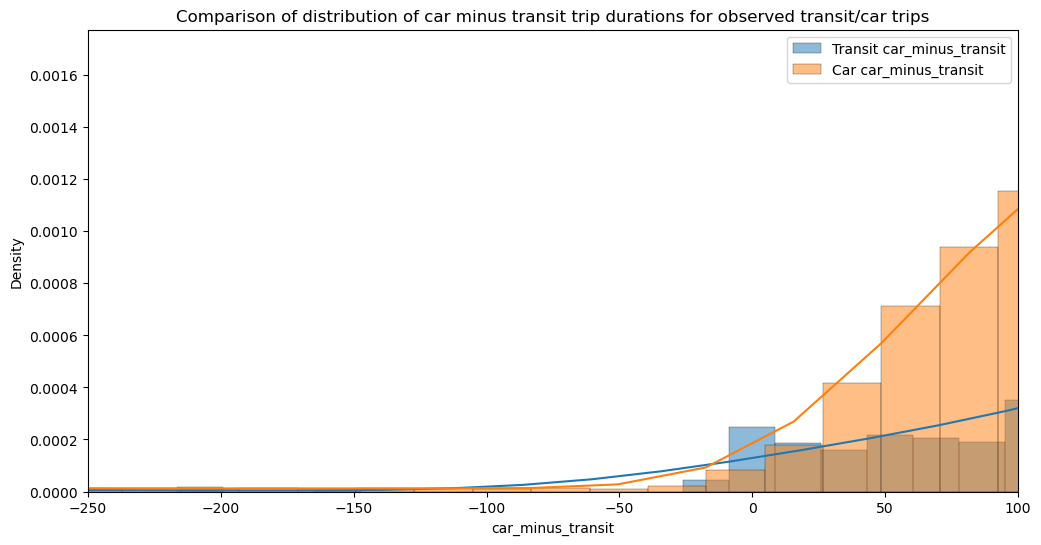

In [29]:
#| output: true

fig, ax = plot_mode_density(df, [('Transit','car_minus_transit'), ('Car','car_minus_transit')], percentile= 1 - MAX_PROBABLE_DIST_PCT) 
ax.set_xlim(-250, 100)
plt.title("Comparison of distribution of car minus transit trip durations for observed transit/car trips")

The summary statistics for this graph can be found below.

In [30]:
#| output: true

show_summaries(df, modes=[('Transit','car_minus_transit'), ('Car','car_minus_transit')], percentile= 1 - MAX_PROBABLE_DIST_PCT)

,Transit car_minus_transit,Car car_minus_transit
count,9022.000000,204305.000000
mean,655.898555,458.785243
std,378.539346,363.321795
min,-1808.650000,-2170.633333
25%,383.441667,218.766667
50%,604.941667,384.716667
75%,872.179167,645.833333
max,3383.666667,4421.183333


In [31]:
df["duration_minus_transit"] = df["duration"] - df["transit_duration"]
df[df["mode"] == "Car"]["duration_minus_transit"].describe(percentiles=[0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95])

count    204306.000000
mean        -37.888511
std         218.088399
min       -2843.300000
25%         -22.383333
50%          -8.050000
75%           7.600000
80%           9.400000
85%          11.200000
90%          14.200000
95%          19.700000
max         855.800000
Name: duration_minus_transit, dtype: float64

In [32]:
#| output: true

df["likely_transit_car_duration_diff"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_transit_shift"])]["vmt"].sum()

df.loc[df["duration_minus_transit"] < -1 * MAX_PROBABLE_DIST, 'likely_transit_shift'] = False
df.loc[df["duration_minus_transit"] < -1 * MAX_PROBABLE_DIST, 'likely_transit_car_duration_diff'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")


Before constraint  100.0  percent of car trips could shift to biking.
After constraint  64.02112517498263  percent of car trips could shift to biking.


In [33]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_transit_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to transit.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to transit.".format(df[(df["mode"] == "Car") & (df["likely_transit_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 100.0% of VMT could be mitigated by switches to transit.
After this constraint, 38.034458070018076% of VMT could be mitigated by switches to transit.


## 2. Timing

As discussed in the feasibility analysis, a trip was considered feasible timing-wise if the actor could work around all discretionary trips (possibly skipping them and doing them another time) to manage to reach all non-negotiable, non-discretionary trips. However, it is not necessarily the case that the actor would be more likely to embark on a trip if they needed to abandon some of their daily activities like shopping or social visits. 

As an example, consider a daily activity pattern consisting of going from home to work, from work to shop, and finally, from shopping back to home. A feasible trip would allow the shoppign trip to be skipped (put off for another time), while a more likely trip would facilitate going on the shopping trip still.

Therefore, we consider a trip most likely to switch if, even with the duration increases that come with switching to non-car modes, the daily acitivies can still be done without any overlaps/need to skip any of them to make to the next.

In [34]:
#| echo: true

fixed_purposes = ["Work", "Work-related", "Escort", "School", "School-related"]

In [35]:
def convert_to_minutes(str):
    hours, minutes, seconds = [int(x) for x in str.split(":")]
    return hours * 60 + minutes + seconds / 60

def evaluate_timing(df, alt_mode_times):
    return df.groupby(["wave", "person_id", "travel_date"]).apply(lambda x: evaluate_probable_timing(x, alt_mode_times))


def evaluate_probable_timing(chunk, alt_mode_times: str):
    # if there is only an inbound and outbound trip, don't need to worry about timing
    if len(chunk) == 2:
        return True
    leg_starts = chunk["depart_time"].apply(lambda x: convert_to_minutes(x)).values
    ref = leg_starts[0]
    # start times, starting by 0 and accounting for midnight wraparound with the mod function, for each leg of the complete tour
    leg_starts = [(x - ref) % 1440 for x in chunk["depart_time"].apply(lambda x: convert_to_minutes(x)).values]
    leg_durations = chunk["duration"].values
    # calculate end times relative to the start times using the duration category
    leg_ends = [(x + y) for (x, y) in zip(leg_starts, leg_durations)]
    # these are arrays indicating whether each leg of the complete tour is a fixed arrival/departure
    fixed_arrivals = chunk["d_purpose_category"].isin(fixed_purposes).values
    fixed_departures = chunk["o_purpose_category"].isin(fixed_purposes).values
    
    # sanity check; if the atlernative time for any of the legs can't be found, return False (means can't route it feasibly, usually for transit)
    # do this as preprocessing
    # if ~(chunk["trip_id"].isin(alt_mode_times.index).any()):
    #     return False
    # alternative durations for each of the legs
    alt_durations = chunk[alt_mode_times].values # make it a col in the dataframe to simplify things
    if -1 in alt_durations:
        return True
    
    # need to omit this for probable -- could have other, non-fixed trips in a tour
    # if fixed_arrivals.sum() <= 1:
    #     return True
    
    for i in range(1, len(chunk) - 1):# can always neglect trip 0 (just leave earlier) and the last trip (just arrive later)
        # if the current trip is fixed arrival
        if fixed_arrivals[i]:
            # for probable, consider ALL adjacent trips; not just adjacent trips that are fixed
            # if you would need to start before the last trip finished, not feasible
            if leg_ends[i] - alt_durations[i] < leg_ends[i - 1]: 
                return False
        # if the current trip is fixed departure
        if fixed_departures[i]:
            # if you would arrive after the next trip began, not feasible
            if leg_starts[i] + alt_durations[i] > leg_starts[i + 1]: 
                return False

    # feasible if nothing is weird
    return True

### 2a. Biking

In [36]:
likely_biking = evaluate_timing(df, "bike_duration")

In [37]:
likely_biking.sum() / len(likely_biking)

0.8660694945273378

In [38]:
likely_biking = likely_biking.reset_index().rename(columns={0: "likely_biking"})
df = df.merge(likely_biking, on=["wave", "person_id", "travel_date"], how="left")

In [39]:
df["likely_biking"].sum() / len(df["likely_biking"])

0.7768617660656496

In [40]:
#| output: true

df["likely_timing_biking"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum()

df.loc[~df["likely_biking"], 'likely_bike_shift'] = False
df.loc[~df["likely_biking"], 'likely_timing_biking'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")


Before constraint  27.407907746223803  percent of car trips could shift to biking.
After constraint  22.015995614421506  percent of car trips could shift to biking.


In [41]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_bike_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to biking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to biking.".format(df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 13.005465936681611% of VMT could be mitigated by switches to biking.
After this constraint, 10.488018821273183% of VMT could be mitigated by switches to biking.


### 2b. Walking

In [42]:
likely_walking = evaluate_timing(df, "walk_duration")

In [43]:
likely_walking.sum() / len(likely_walking)

0.8547928798053032

In [44]:
likely_walking = likely_walking.reset_index().rename(columns={0: "likely_walking"})
df = df.merge(likely_walking, on=["wave", "person_id", "travel_date"], how="left")

In [45]:
df["likely_walking"].sum() / len(df["likely_walking"])

0.7584539990753583

In [46]:
#| output: true

df["likely_timing_walking"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum()

df.loc[~df["likely_walking"], 'likely_walk_shift'] = False
df.loc[~df["likely_walking"], 'likely_timing_walking'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")


Before constraint  30.198329956046322  percent of car trips could shift to biking.
After constraint  23.779526788249  percent of car trips could shift to biking.


In [47]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_walk_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to walking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to walking.".format(df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 8.036651434458813% of VMT could be mitigated by switches to walking.
After this constraint, 6.33662676925961% of VMT could be mitigated by switches to walking.


### 2c. Transit

In [48]:
likely_transit = evaluate_timing(df, "transit_duration")

In [49]:
likely_transit.sum() / len(likely_transit)

0.920133535505409

In [50]:
likely_transit = likely_transit.reset_index().rename(columns={0: "likely_transit"})
df = df.merge(likely_transit, on=["wave", "person_id", "travel_date"], how="left")

In [51]:
df["likely_transit"].sum() / len(df["likely_transit"])

0.8629052242256126

In [52]:
#| output: true

df["likely_timing_transit"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to transit.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_transit_shift"])]["vmt"].sum()

df.loc[~df["likely_transit"], 'likely_transit_shift'] = False
df.loc[~df["likely_transit"], 'likely_timing_transit'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to transit.")


Before constraint  64.02112517498263  percent of car trips could shift to transit.
After constraint  57.86222626844047  percent of car trips could shift to transit.


In [53]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_transit_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to transit.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to transit.".format(df[(df["mode"] == "Car") & (df["likely_transit_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 38.034458070018076% of VMT could be mitigated by switches to transit.
After this constraint, 34.33385708619176% of VMT could be mitigated by switches to transit.


## 3. Weather (Precipitation > X mm)

Weather plays an important consideration when determining whether a car trip is more likely to switch to an alternative mode, as cars offer a higher baseline for weather tolerance than these alternative modes. This is especially pronounced for biking and walking, which offer no protection to the elements, as seen in the feasibility section with the biking in snow indicator.

We thus consider a shift to biking or walking more likely if it takes place on a low-rain day (by default, we consider no rain).

A comparison of the distribution of precipitation amounts segmented by mode show the importance of precipitation--for bike/scooter and particularly walking, the 95th percentile of precipitation on trips is significantly lower than that for car and transit trips. The walk percentile is not seen at the 95th because it overlaps directly with bike/scooter.

Text(0.5, 1.0, 'Distributions of precipitation during linked trips, segmented by mode')

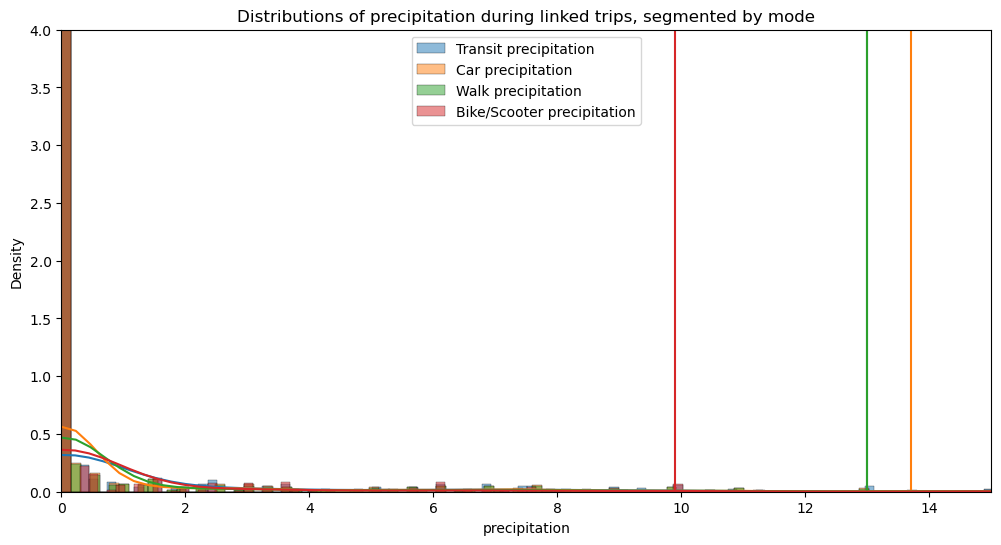

In [54]:
#| output: true

fig, ax = plot_mode_density(df, [('Transit','precipitation'), ('Car','precipitation'), ('Walk','precipitation'), ('Bike/Scooter','precipitation')], percentile=0.95)
ax.set_xlim(0, 15)
ax.set_ylim(0, 4)
plt.title("Distributions of precipitation during linked trips, segmented by mode")

Summary statistics for these distributions are found below.

In [55]:
#| output: true

show_summaries(df, modes=[('Transit','precipitation'), ('Car','precipitation'), ('Walk','precipitation'), ('Bike/Scooter','precipitation')], percentile= 0.95)

,Transit precipitation,Car precipitation,Walk precipitation,Bike/Scooter precipitation
count,9022.000000,204306.00000,46658.000000,6846.000000
mean,2.272866,2.24479,1.987891,1.640681
std,5.816107,5.99861,5.653847,5.287859
min,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.00000,0.000000,0.000000
50%,0.000000,0.00000,0.000000,0.000000
75%,1.000000,0.80000,0.300000,0.000000
95%,13.000000,13.70000,13.000000,9.900000
max,44.200000,46.50000,46.500000,44.200000


By restricting the most likely walking/biking shifts to non-rainy days, we reduce the universe of the feasible car trips that are most likely to switch to walking/biking by a fair amount.

In [56]:
#| output: true

df["likely_precipitation_walk"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum()

df.loc[df["precipitation"] != 0, 'likely_walk_shift'] = False
df.loc[df["precipitation"] != 0, 'likely_precipitation_walk'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to walking.")


Before constraint  23.779526788249  percent of car trips could shift to walking.
After constraint  15.839476079997649  percent of car trips could shift to walking.


In [57]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_walk_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to transit.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to transit.".format(df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 6.33662676925961% of VMT could be mitigated by switches to transit.
After this constraint, 4.270736555691221% of VMT could be mitigated by switches to transit.


In [58]:
#| output: true

df["likely_precipitation_bike"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum()

df.loc[df["precipitation"] != 0, 'likely_bike_shift'] = False
df.loc[df["precipitation"] != 0, 'likely_precipitation_bike'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")

Before constraint  22.015995614421506  percent of car trips could shift to biking.
After constraint  14.589879886053273  percent of car trips could shift to biking.


In [59]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_bike_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to biking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to biking.".format(df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 10.488018821273183% of VMT could be mitigated by switches to biking.
After this constraint, 7.022852366686864% of VMT could be mitigated by switches to biking.


## 4. Temperature > X degrees

A tangential topic to rainfall in the topic of likely walk/bike shifts is temperature. As with rainfall, the modes of walking/biking are far more susceptible to temperature than car/transit trips are, making it another consideration for whether a trip shift is more likely to switch.

Here, we consider a bike/walk trip more likely if it can be done in 12 degrees Celsius or above.

A distribution of average temperatures over the day a linked trip occurred on segmented by mode can be seen below. As with duration difference, we flip the percentile for a more meaningful analysis. Also observe that biking/walking trips tend to occur in higher temperatures than transit/car, reflecting the reasoning discussed earlier.

Text(0.5, 1.0, 'Distributions of temperature during linked trips, segmented by mode')

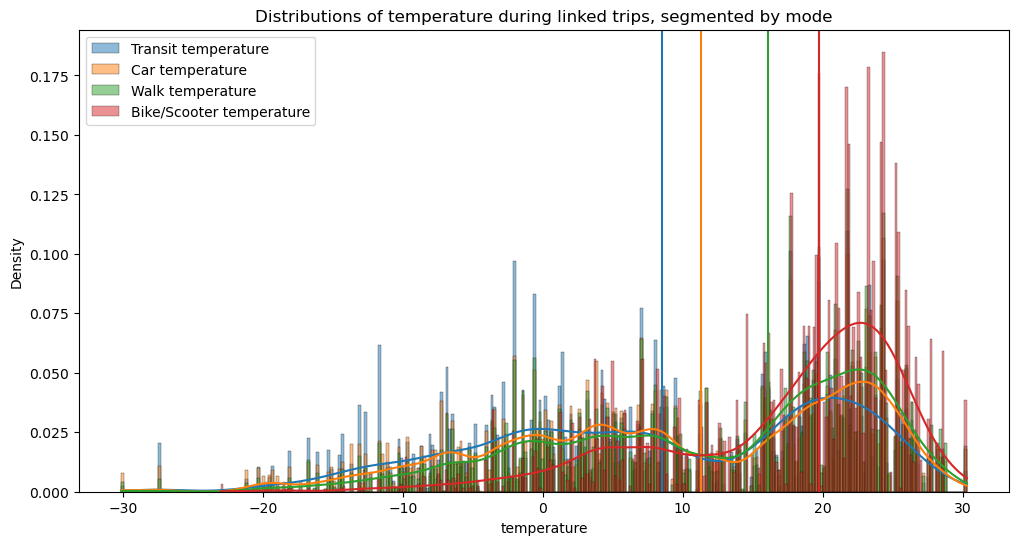

In [60]:
#| output: true

fig, ax = plot_mode_density(df, [('Transit','temperature'), ('Car','temperature'), ('Walk','temperature'), ('Bike/Scooter','temperature')], percentile=1-MAX_PROBABLE_DIST_PCT)
plt.title("Distributions of temperature during linked trips, segmented by mode")

The summary statistics for this graph can be found below.

In [61]:
#| output: true

show_summaries(df, modes=[('Transit','temperature'), ('Car','temperature'), ('Walk','temperature'), ('Bike/Scooter','temperature')], percentile= 0.95)

,Transit temperature,Car temperature,Walk temperature,Bike/Scooter temperature
count,9022.000000,204306.000000,46658.000000,6846.000000
mean,8.645533,10.088153,12.187706,17.033961
std,12.531238,12.479369,11.619948,8.928987
min,-30.100000,-30.100000,-30.100000,-23.000000
25%,-0.800000,0.400000,3.300000,12.100000
50%,8.500000,11.300000,16.100000,19.700000
75%,19.700000,21.400000,21.800000,23.400000
95%,25.400000,26.000000,26.100000,26.800000
max,30.300000,30.300000,30.300000,30.300000


When applying this temperature restrictions, a non-insignifciant percent of car trips can no longer liekely switch to biking/walking.

In [62]:
#| output: true

df["likely_temperature_walk"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum()

df.loc[df["temperature"] < 12, 'likely_walk_shift'] = False
df.loc[df["temperature"] < 12, 'likely_temperature_walk'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to walking.")


Before constraint  15.839476079997649  percent of car trips could shift to walking.
After constraint  7.257740839720811  percent of car trips could shift to walking.


In [63]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_walk_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to walking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to walking.".format(df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 4.270736555691221% of VMT could be mitigated by switches to walking.
After this constraint, 2.116581731956883% of VMT could be mitigated by switches to walking.


In [64]:
#| output: true

df["likely_temperature_bike"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum()

df.loc[df["temperature"] < 12, 'likely_bike_shift'] = False
df.loc[df["temperature"] < 12, 'likely_temperature_bike'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")

Before constraint  14.589879886053273  percent of car trips could shift to biking.
After constraint  7.012520435033724  percent of car trips could shift to biking.


In [65]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_bike_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to biking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to biking.".format(df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 7.022852366686864% of VMT could be mitigated by switches to biking.
After this constraint, 3.6445463116542216% of VMT could be mitigated by switches to biking.


## 5. Number of transfers > X transfers

Transfers are a very costly and inconvenient part of going on transit, which makes it a good indicator for whether a trip can more likely switch to transit. Here, we only consider transit trips that require 0 transfers more likely.

As seen in the feasibility analysis, the rerouted transfer coutns are reasonably accurate when compared to the approximated transfer counts, although they do display substantially less variability.

Text(0.5, 1.0, 'Re-routed transfer counts for canonical transit trips')

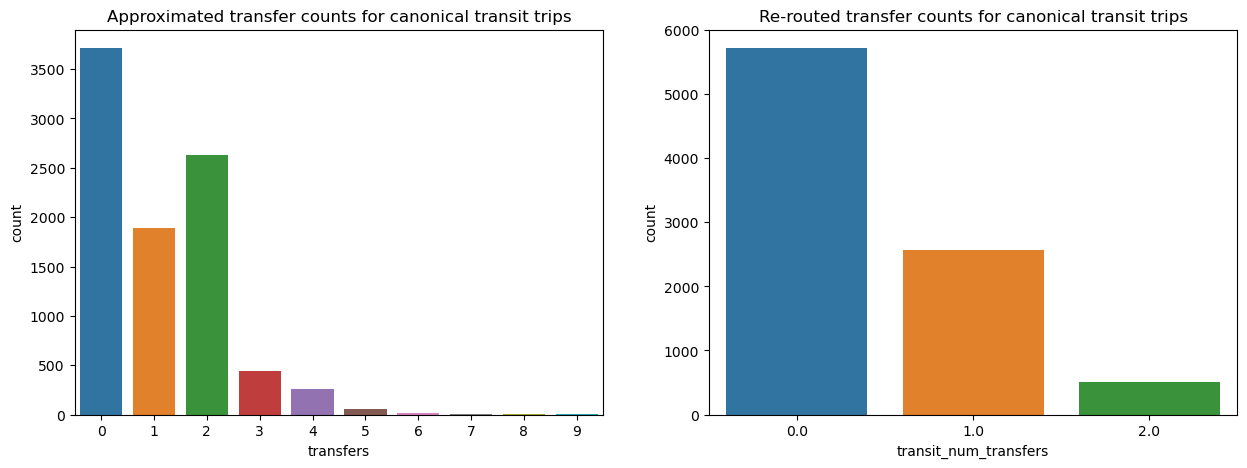

In [66]:
#| output: true
# check how the calculated transfer count for car trips compare to the observed transfer count for transit trips
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x="transfers", data=df[df["mode"] == "Transit"], ax=ax[0])
sns.countplot(x="transit_num_transfers", data=df[df["mode"] == "Transit"], ax=ax[1])
ax[0].set_title("Approximated transfer counts for canonical transit trips")
ax[1].set_title("Re-routed transfer counts for canonical transit trips")

We thus use the rerouted transfer counts to directly compare the transfer distributions for observed car and transit trips, which is seen below. Observe that the number of transfers for observed transit trips are more left-skewed than those for observed car trips, showing that transfer number is indeed an important indicator for trip likelihood (this could be a reflection of rerouting restrictions, though).

Text(0.5, 1.0, 'Re-routed optimized transfer counts for canonical car trips')

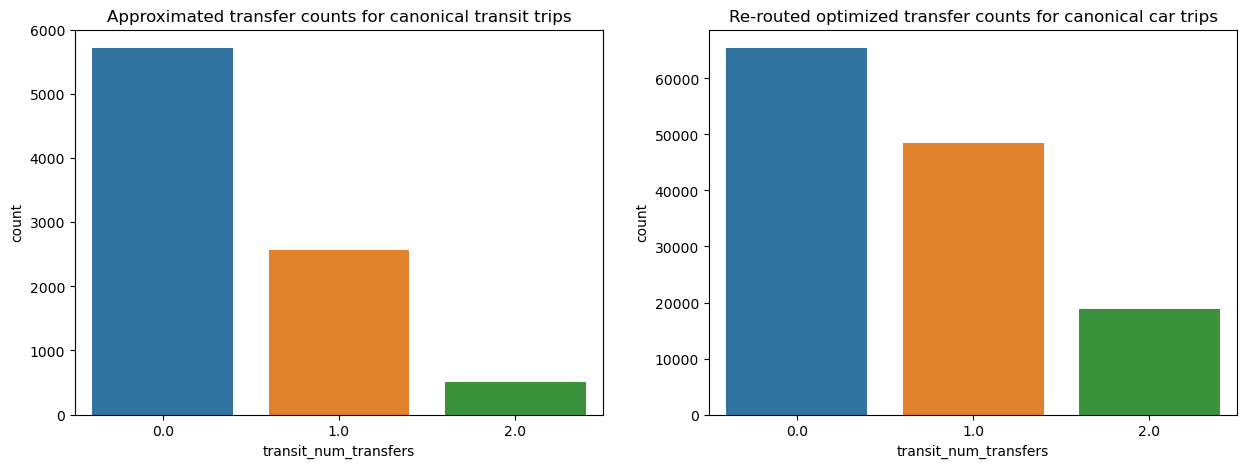

In [67]:
#| output: true

# compare observed distribution of transfer count to calculated distribution of transfer count 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x="transit_num_transfers", data=df[df["mode"] == "Transit"], ax=ax[0])
sns.countplot(x="transit_num_transfers", data=df[df["mode"] == "Car"], ax=ax[1])
# it seems the calculated transfer count distribution seems to have a hard cap at 2 and varies less than the observed count
# we will use the observed transfers as a cutoff--max 3 transfers for feasibility
ax[0].set_title("Approximated transfer counts for canonical transit trips")
ax[1].set_title("Re-routed optimized transfer counts for canonical car trips")

By limiting the most likely transit trip shifts to those that can be done in zero transfers, we cut down the percent of car trips that can shift to transit substantially.

In [68]:
#| output: true

df["likely_transfer_transit"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to transit.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_transit_shift"])]["vmt"].sum()

df.loc[df["transit_num_transfers"] > MAX_PROBABLE_TRANFERS, 'likely_transit_shift'] = False
df.loc[df["transit_num_transfers"] > MAX_PROBABLE_TRANFERS, 'likely_transfer_transit'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to transit.")

Before constraint  57.86222626844047  percent of car trips could shift to transit.
After constraint  53.35819799712196  percent of car trips could shift to transit.


In [69]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_transit_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to transit.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to transit.".format(df[(df["mode"] == "Car") & (df["likely_transit_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 34.33385708619176% of VMT could be mitigated by switches to transit.
After this constraint, 29.051672331791558% of VMT could be mitigated by switches to transit.


## 6. Purpose

Some trip purposes cannot be switched from modes that facilitate them better--e.g., car for shopping trips. As such, we will consider any car trip that involves escorting someone or shopping to be less likely to switch to an alternative mode. 

In [70]:
# merging some closely related categories
df["purpose_cleaned"] = df["d_purpose_category"]
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["School", "School-related"]), "School", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Work", "Work-related"]), "Work", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Errand/Other", "Errand"]), "Errand", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Shop", "Shopping"]), "Shop", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Missing: Non-response", "Missing: Skip logic", "Not imputable"]), "Missing", df["purpose_cleaned"])

Below, we can see the distribution of all the cleaned purposes in the TBI data. As can be seen, the most popular trip purposes are the fundamental, primary ones like going to work or returnign home.

Text(0.5, 1.0, 'Count plot of the cleaned destination purposes in the TBI data')

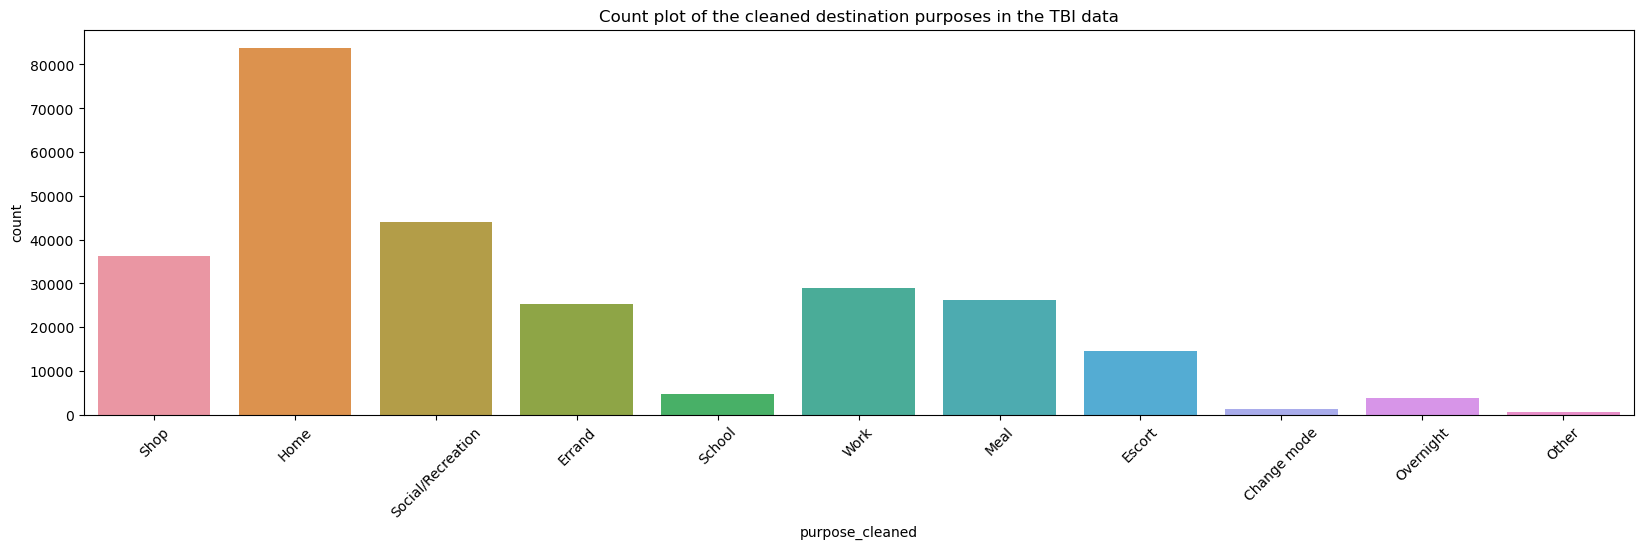

In [71]:
#| output: true

# overall distribution
fig, ax = plt.subplots(figsize=(20, 5))
sns.countplot(x="purpose_cleaned", data=df[df["purpose_cleaned"] != "Missing"], ax=ax)
plt.xticks(rotation=45)
plt.title("Count plot of the cleaned destination purposes in the TBI data")

Below, we can see the same graph segmented by graph. As alluded to earlier, some purposes are done with certain modes at a much higher frequency than others--e.g., cars with escorting tasks. 

Text(0.5, 1.0, 'Count plot of the cleaneddestination purposes in the TBI data, segmented by mode')

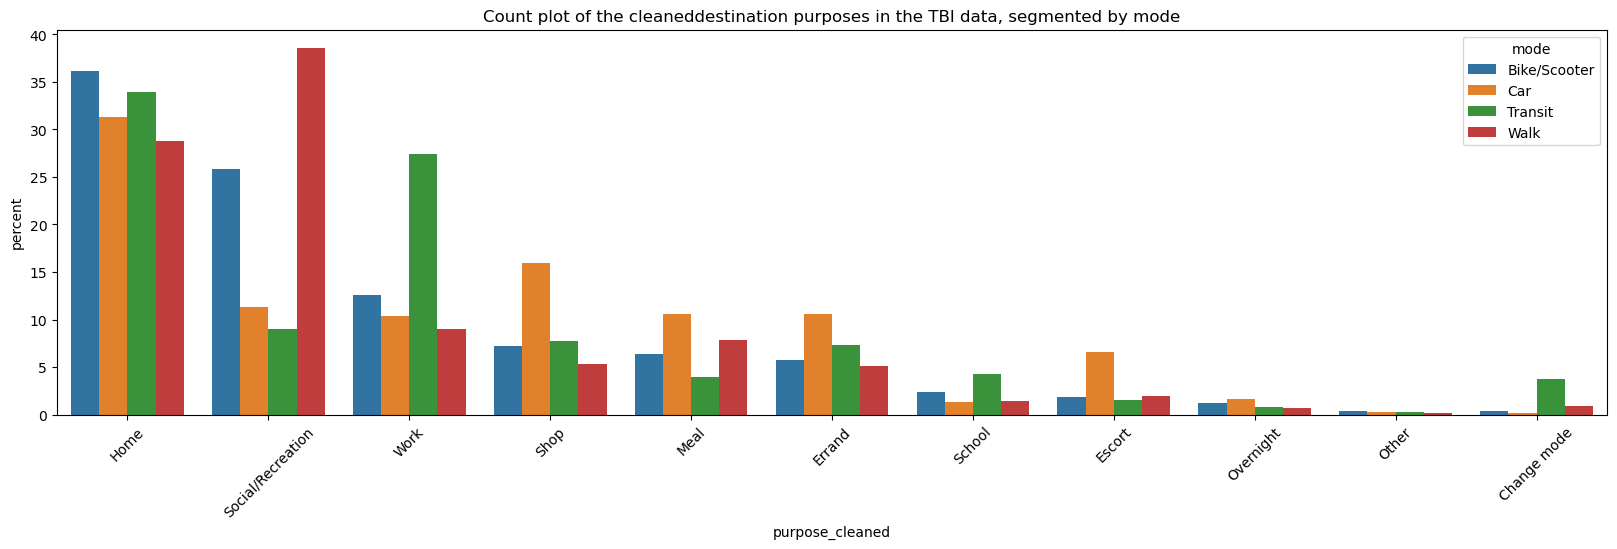

In [72]:
#| output: true

# purpose segmented by mode -- % of all mode trips in each purpose category
# notable features: social/recreation is predominantly walking, errands/shopping/escorts are mostly car
fig, ax = plot_multi_barplot(df[df["purpose_cleaned"] != "Missing"], "purpose_cleaned", "mode", figsize=(20, 5))
plt.xticks(rotation=45)
plt.title("Count plot of the cleaneddestination purposes in the TBI data, segmented by mode")

With this restriction, we reduce the percentage of trips that can most likely shift to alternative modes once again.

In [73]:
#| output: true

df["likely_purpose_bike"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum()

df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_bike_shift'] = False
df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_purpose_bike'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")

Before constraint  7.012520435033724  percent of car trips could shift to biking.
After constraint  5.714956976300256  percent of car trips could shift to biking.


In [74]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_bike_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to biking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to biking.".format(df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 3.6445463116542216% of VMT could be mitigated by switches to biking.
After this constraint, 3.077206583206449% of VMT could be mitigated by switches to biking.


In [75]:
#| output: true

df["likely_purpose_walk"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum()

df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_walk_shift'] = False
df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_purpose_walk'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to walking.")

Before constraint  7.257740839720811  percent of car trips could shift to walking.
After constraint  5.255352265719068  percent of car trips could shift to walking.


In [76]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_walk_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to walking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to walking.".format(df[(df["mode"] == "Car") & (df["likely_walk_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 2.116581731956883% of VMT could be mitigated by switches to walking.
After this constraint, 1.6201255739543137% of VMT could be mitigated by switches to walking.


In [77]:
#| output: true

df["likely_purpose_transit"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to transit.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_transit_shift"])]["vmt"].sum()

df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_transit_shift'] = False
df.loc[df["purpose_cleaned"].isin(unlikely_purposes), 'likely_purpose_transit'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_transit_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to transit.")

Before constraint  53.35819799712196  percent of car trips could shift to transit.
After constraint  40.33998022573982  percent of car trips could shift to transit.


In [78]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_transit_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to transit.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to transit.".format(df[(df["mode"] == "Car") & (df["likely_transit_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 29.051672331791558% of VMT could be mitigated by switches to transit.
After this constraint, 23.186406613430897% of VMT could be mitigated by switches to transit.


## 7. Distance on LTS 3 + 4 > X meters

In the feasibility analysis, we had a similar constraint on the % of LTS, but now, we impose a stricter restriction on high stress distance--specifically 0 (by default).

In [79]:
df["high_stress_biking_distance"] = df["bike_distance_meters_3"] + df["bike_distance_meters_4"]
df["high_stress_biking_pct"] = df["high_stress_biking_distance"] / df["bike_distance_meters"]

The comparison of the distribution between bike/car lts distance can be seen below. This reflects what was seen in the feasibilty analysis, with bike trips tending to have lower absolute lts distances.

(0.0, 500.0)

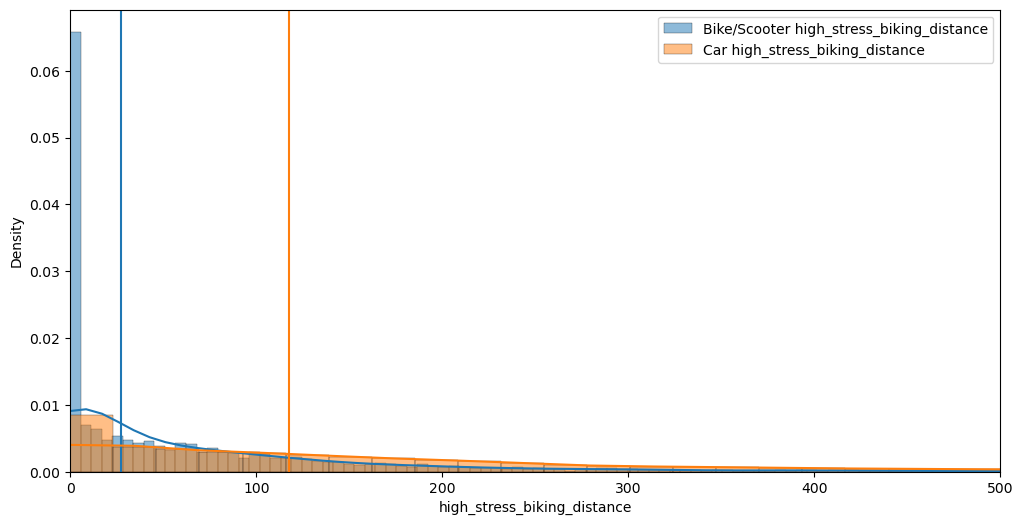

In [80]:
#| output: true

# comparing distribution of amount of high stress biking distance existing biking trips have to go through to that potentially switching car trips would have to travel through
# anything to the left of the blue line is within the 95th percentile of high stress biking distance for existing bikers and is thus an upper bound
fig, ax = plot_mode_density(df, modes=[("Bike/Scooter", "high_stress_biking_distance"), ("Car", "high_stress_biking_distance")], percentile=MAX_HIGH_LTS_DIST_BIKE_PCT)
ax.set_xlim(left=0, right=500)
# we will use 250m as a lower cutoff

The summary statistics can be found below.

In [81]:
#| output: true

show_summaries(df, modes=[("Bike/Scooter", "high_stress_biking_distance"), ("Car", "high_stress_biking_distance")], percentile= MAX_HIGH_LTS_DIST_BIKE_PCT)

,Bike/Scooter high_stress_biking_distance,Car high_stress_biking_distance
count,6846.000000,204306.000000
mean,73.230384,194.581702
std,126.958658,243.813032
min,0.000000,0.000000
25%,0.000000,37.674109
50%,27.505559,117.479603
75%,96.426383,247.797141
max,1696.548173,6946.157909


In [82]:
#| output: true

df["likely_highlts_bike"] = True

percent_before = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to biking.")

prev_vmt = df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum()

df.loc[df["high_stress_biking_distance"] > MAX_HIGH_LTS_DIST_BIKE, 'likely_bike_shift'] = False
df.loc[df["high_stress_biking_distance"] > MAX_HIGH_LTS_DIST_BIKE, 'likely_highlts_bike'] = False

percent_after = len(df[(df['mode']=='Car') & (df['likely_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_after , " percent of car trips could shift to biking.")

Before constraint  5.714956976300256  percent of car trips could shift to biking.
After constraint  2.0674870047869374  percent of car trips could shift to biking.


In [83]:
#| output: true

reduced_vmt = df[(df["mode"] == "Car") & df["likely_bike_shift"]]["vmt"].sum()
print("Before this constraint, {0}% of VMT could be mitigated by switches to biking.".format(prev_vmt / df[(df["mode"] == "Car")]["vmt"].sum() * 100))
print("After this constraint, {0}% of VMT could be mitigated by switches to biking.".format(df[(df["mode"] == "Car") & (df["likely_bike_shift"])]["vmt"].sum() / df[(df["mode"] == "Car")]["vmt"].sum() * 100))

Before this constraint, 3.077206583206449% of VMT could be mitigated by switches to biking.
After this constraint, 1.0013265709792059% of VMT could be mitigated by switches to biking.


# Overall statistics

Similar to the feasibility analysis, we can report overall statistics/metrics for the most likely mode shifts.

In [84]:
#| echo: true
df["likely_shift"] = df["likely_transit_shift"] | df["likely_walk_shift"] | df["likely_bike_shift"]

In [85]:
#| output: true
print("Percent of car trips that can likely switch to an alterantive mode (bike, walk, or transit):")
print(df[df["mode"] == "Car"]["likely_shift"].sum() / len(df[df["mode"] == "Car"]))
print()

Percent of car trips that can likely switch to an alterantive mode (bike, walk, or transit):
0.4131400937808973



In [86]:
#| output: true
print("Total number of person trips on car before applying likely mode shift:")
print(len(df[df["mode"] == "Car"]))
print("Total number of person trips on car after applying likely mode shift:")
print(len(df[(df["mode"] == "Car") & (~df["likely_shift"])]))
print()

Total number of person trips on car before applying likely mode shift:
204306
Total number of person trips on car after applying likely mode shift:
119899



In [87]:
#| output: true
print("Total number of vehicle trips on car before applying likely mode shift:")
print(df[df["mode"] == "Car"]["vehicle_trips"].sum())
print("Total number of vehicle trips on car after applying likely mode shift:")
print(df[(df["mode"] == "Car") & (~df["likely_shift"])]["vehicle_trips"].sum())
print()

Total number of vehicle trips on car before applying likely mode shift:
148393.57965367966
Total number of vehicle trips on car after applying likely mode shift:
88426.5331168831



In [88]:
#| output: true
print("Total VMT before applying likely mode shift:")
print(df[df["mode"] == "Car"]["vmt"].sum())
print("Total VMT after applying likely mode shift:")
print(df[(df["mode"] == "Car") & (~df["likely_shift"])]["vmt"].sum())
print()

Total VMT before applying likely mode shift:
574196.7096061147
Total VMT after applying likely mode shift:
437602.9117119746



In [89]:
COLD_START_THRESHOLD = 15

def get_num_cold_starts(chunk):
    leg_starts = chunk["depart_time"].apply(lambda x: convert_to_minutes(x)).values
    ref = leg_starts[0]
    # start times, starting by 0 and accounting for midnight wraparound with the mod function, for each leg of the complete tour
    leg_starts = [(x - ref) % 1440 for x in chunk["depart_time"].apply(lambda x: convert_to_minutes(x)).values]
    leg_durations = chunk["duration"].values
    # calculate end times relative to the start times using the duration category
    leg_ends = [(x + y) for (x, y) in zip(leg_starts, leg_durations)]
    modes = chunk["mode"].values
    
    cold_starts = 0
    prev_end = -1
    # iterate over all trips in a complete tour
    for i in range(len(leg_starts)):
        # if the current leg mode i car
        if modes[i] == "Car":
            # if there wasn't a previous or the difference between the end of the last car trip and the beginning of this car trip is more than 15 minutes, it is a cold start
            if prev_end == -1 or leg_starts[i] - leg_ends[i] > COLD_START_THRESHOLD:
                cold_starts += 1
            # update previous end of car trip
            prev_end = leg_ends[i]
    return cold_starts            

In [90]:
#| output: true
print("Number of cold starts before applying likely mode shifts:")
print(df[df["mode"] == "Car"].groupby(["wave", "person_id", "travel_date"]).apply(lambda x: get_num_cold_starts(x)).sum())
print("Number of cold starts after applying feasible mode shifts:")
print(df[(df["mode"] == "Car") & (~df["likely_shift"])].groupby(["wave", "person_id", "travel_date"]).apply(lambda x: get_num_cold_starts(x)).sum())
print()

Number of cold starts before applying likely mode shifts:
67001
Number of cold starts after applying feasible mode shifts:
48975



Exporting results with the trips that are flagged as the most likely to switch for further analysis:

In [91]:
#| echo: true
df.to_csv(data_dir + "/data_processed/likely_shifts.csv")

In [92]:
# make it configurable -- give it a set of parameters and have it spit out graphs/analysis
